# Beans Disease Classification

We are going to use the [Beans dataset](https://www.tensorflow.org/datasets/catalog/beans) from TensorFlow Datasets.

It has **3 classes**: two diseased classes (*angular leaf spot* and *bean rust*) and one healthy class. This is a real-world agricultural classification problem.

The goal for today is:
1. Build a simple CNN from scratch and see what accuracy we can get
2. Apply transfer learning using a pre-trained model and compare the result

**Important:** Today we are using the validation set to compare models. We will **not** touch the test set until the very end, after we have chosen our best model.

In [1]:
import tensorflow as tf
import numpy as np
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras import layers

## Loading the Data

Some datasets in TensorFlow Datasets come with pre-defined splits. Beans already has `train`, `validation`, and `test` splits, so we can load all three directly.

If a dataset only has a `train` split, you would have to create your own test and validation sets manually — as you will be doing in the project.

In [2]:
# This will download the dataset on the first run -- run this cell now
# and let it download while we read through the rest of the notebook
train_ds, validation_ds, test_ds = tfds.load(
    "beans",
    split=['train', 'validation', 'test'],
    as_supervised=True  # returns (image, label) pairs
)

num_classes = 3

## Data Exploration

Before building any model, always understand your data first.

In [3]:
print(f"Training samples:   {train_ds.cardinality()}")
print(f"Validation samples: {validation_ds.cardinality()}")
print(f"Test samples:       {test_ds.cardinality()}")

Training samples:   1034
Validation samples: 133
Test samples:       128


### Class Distribution

Is the dataset balanced? An imbalanced dataset means accuracy alone can be misleading.

**Task:** Extract the labels from `train_ds` and plot a bar chart showing how many images there are per class. The class names are `['angular_leaf_spot', 'bean_rust', 'healthy']` (labels 0, 1, 2).

In [16]:
class_names = ['angular_leaf_spot', 'bean_rust', 'healthy']

# Extract all labels from the training set
train_labels = np.array([label.numpy() for _, label in train_ds])

# --- Your code here ---
# Plot a bar chart of class counts
# Hint: use np.unique with return_counts=True, then plt.bar
np.unique(train_labels, return_counts=True)

(array([0, 1, 2]), array([345, 348, 341]))

In [12]:
plt.bar?

Signature:
plt.bar(
    x: 'float | ArrayLike',
    height: 'float | ArrayLike',
    width: 'float | ArrayLike' = 0.8,
    bottom: 'float | ArrayLike | None' = None,
    *,
    align: "Literal['center', 'edge']" = 'center',
    data=None,
    **kwargs,
) -> 'BarContainer'
Docstring:
Make a bar plot.

The bars are positioned at *x* with the given *align*\ment. Their
dimensions are given by *height* and *width*. The vertical baseline
is *bottom* (default 0).

Many parameters can take either a single value applying to all bars
or a sequence of values, one for each bar.

Parameters
----------
x : float or array-like
    The x coordinates of the bars. See also *align* for the
    alignment of the bars to the coordinates.

    Bars are often used for categorical data, i.e. string labels below
    the bars. You can provide a list of strings directly to *x*.
    ``bar(['A', 'B', 'C'], [1, 2, 3])`` is often a shorter and more
    convenient notation compared to
    ``bar(range(3), [1, 2, 3], ti

In [5]:
train_labels

array([1, 1, 0, ..., 2, 1, 0], shape=(1034,))

### Sample Images

Let's look at some examples. Can you see visual differences between the classes?

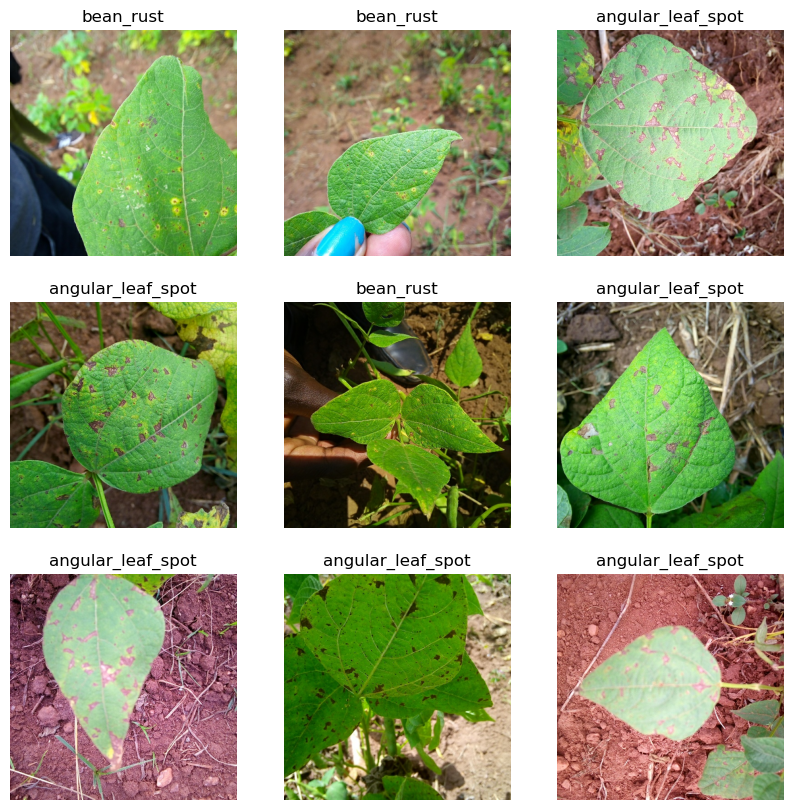

In [17]:
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(train_ds.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[int(label)])
    plt.axis("off")

**Task:** What are the original image dimensions? Write a line of code to print the shape of one image from the training set.

In [23]:
# --- Your code here ---
# Print the shape of the first image in train_ds
train_ds.take(2)

<_TakeDataset element_spec=(TensorSpec(shape=(500, 500, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

## Part 1 — CNN from Scratch

We will resize all images to $150 \times 150$ to keep training fast. The Rescaling layer inside the model will normalise pixel values to $[0, 1]$ at training time.

We keep a copy of the original datasets so we can easily try a different size later for the transfer learning part.

In [24]:
IMAGE_SIZE = 150
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

resize_fn = tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE)

train150_ds = (
    train_ds
    .map(lambda x, y: (resize_fn(x), y))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
validation150_ds = (
    validation_ds
    .map(lambda x, y: (resize_fn(x), y))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
test150_ds = (
    test_ds
    .map(lambda x, y: (resize_fn(x), y))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

### Model Definition

A straightforward CNN: three Conv+Pool blocks, then GlobalAveragePooling2D to collapse the spatial dimensions, one Dense hidden layer, and a 3-unit output.

A few things to note:
- The output layer has **no activation**. We use `from_logits=True` in the loss function, which is numerically more stable than applying softmax and then computing log-loss.
- We are not using BatchNormalization here to keep the model simple. You would typically add it in a production model.
- We are keeping the architecture modest intentionally — you may well see signs of underfitting, which is the motivation for trying transfer learning.

In [25]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)   # no activation -- from_logits=True in loss
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 150, 150, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 75, 75, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 75, 75, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 37, 37, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 37, 37, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 18, 18, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,291 (126.14 KB)

 Trainable params: 32,291 (126.14 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

### Training

We train for 20 epochs. Early stopping could be used here to automatically find a good stopping point, but the focus of today is on comparing scratch vs transfer learning, so we keep it simple.

Watch both `accuracy` and `val_accuracy` as it trains. What do you notice about the gap between them?

In [27]:
history = model.fit(
    train150_ds,
    validation_data=validation150_ds,
    epochs=20
)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 138ms/step - accuracy: 0.3511 - loss: 1.0946 - val_accuracy: 0.6391 - val_loss: 1.0685
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.4758 - loss: 1.0164 - val_accuracy: 0.4361 - val_loss: 0.9851
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.4990 - loss: 0.9711 - val_accuracy: 0.5865 - val_loss: 0.9133
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.6180 - loss: 0.8881 - val_accuracy: 0.5338 - val_loss: 0.8512
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.5716 - loss: 0.8960 - val_accuracy: 0.6391 - val_loss: 0.8249
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.6219 - loss: 0.8313 - val_accuracy: 0.6992 - val_loss: 0.7501
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.6325 - loss: 0.8257 - val_accuracy: 0.6917 - val_loss: 0.7518
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.6518 - loss: 0.7903 - val_accuracy: 0.

### Plotting Training History

**Task:** Plot the training and validation accuracy and loss curves. What do the curves tell you about overfitting or underfitting?

- If training accuracy is much higher than validation accuracy: overfitting
- If both are low and close together: underfitting

Note the final **validation accuracy** — this is the number you will compare against the transfer learning model.

In [ ]:
# --- Your code here ---
# Plot training vs validation accuracy
# Plot training vs validation loss
# (two separate plots, or two subplots side by side)


**Discussion:** If training accuracy is below around 80%, the model is likely underfitting -- a deeper network or more epochs might help. We could also add BatchNormalization or data augmentation. We are going to move on to transfer learning to address this more effectively, but it is worth knowing that improving the scratch model further is a valid path too.

---

## Part 2 — Transfer Learning

Now we will use **Xception** pre-trained on ImageNet as a base model. Xception was trained on millions of images and has already learned to detect edges, textures, and shapes that are useful for almost any image classification task.

The plan:
1. Load Xception with the top (classifier) layers removed
2. Freeze the base model weights
3. Add our own classifier head on top
4. Train only the new head
5. Fine-tune: unfreeze part of the base model and train again at a very low learning rate

Refer to the transfer learning lecture notes and the [Keras guide](https://keras.io/guides/transfer_learning/) for the API.

### Step 1 — Image Size

Xception has a minimum input size. Look it up in the [Keras documentation](https://keras.io/api/applications/xception/) before continuing.

**Task:** Create resized and batched versions of the three datasets for use with Xception. Choose an appropriate image size. Use the same pipeline pattern as above (`.map`, `.batch`, `.prefetch`). Call them `train_xc_ds`, `validation_xc_ds`, `test_xc_ds`.

In [28]:
IMAGE_SIZE = 100
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

resize_fn = tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE)

train_xc_ds = (
    train_ds
    .map(lambda x, y: (resize_fn(x), y))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
validation_xc_ds = (
    validation_ds
    .map(lambda x, y: (resize_fn(x), y))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
test_xc_ds = (
    test_ds
    .map(lambda x, y: (resize_fn(x), y))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

### Step 2 — Load the Base Model

**Task:** Load Xception with:
- `include_top=False` (removes the ImageNet classifier head)
- `weights='imagenet'` (loads pre-trained weights)
- The correct `input_shape` for your chosen image size

Then freeze it. Check the lecture notes for the one-line freeze call.

In [29]:
# --- Your code here ---
base_model = tf.keras.applications.Xception(include_top=False, weights='imagenet', input_shape=(IMAGE_SIZE,IMAGE_SIZE, 3))
# freeze it
# print how many trainable and non-trainable parameters it has

In [30]:
base_model.trainable = False
base_model.summary()

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 100, 100, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1 (Conv2D)         │ (None, 49, 49, 32)        │             864 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1_bn               │ (None, 49, 49, 32)        │             128 │ block1_conv1[0][0]         │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1_act (Activation) │ (None, 49, 49, 32)        │               0 │ block1_conv1_bn[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2 (Conv2D)         │ (None, 47, 47, 64)        │          18,432 │ block1_conv1_act[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2_bn               │ (None, 47, 47, 64)        │             256 │ block1_conv2[0][0]         │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2_act (Activation) │ (None, 47, 47, 64)        │               0 │ block1_conv2_bn[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv1               │ (None, 47, 47, 128)       │           8,768 │ block1_conv2_act[0][0]     │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv1_bn            │ (None, 47, 47, 128)       │             512 │ block2_sepconv1[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2_act           │ (None, 47, 47, 128)       │               0 │ block2_sepconv1_bn[0][0]   │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2               │ (None, 47, 47, 128)       │          17,536 │ block2_sepconv2_act[0][0]  │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2_bn            │ (None, 47, 47, 128)       │             512 │ block2_sepconv2[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 24, 24, 128)       │           8,192 │ block1_conv2_act[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_pool (MaxPooling2D)    │ (None, 24, 24, 128)       │               

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,861,480 (79.58 MB)

### Step 3 — Preprocessing

Xception expects inputs normalised in a specific way -- **not** simply divided by 255. It has its own preprocessing function.

**Task:** Find the correct preprocessing function for Xception in the Keras documentation and apply it in the model below.

### Step 4 — Build the New Model

Using the Functional API (required here because we are grafting onto an existing model), build a model that:
1. Takes an input of your chosen image size
2. Applies the Xception preprocessing function
3. Passes through the frozen base model (`training=False` — check your notes for why this matters with BatchNormalization)
4. Applies `GlobalAveragePooling2D`
5. Adds a `Dense` output layer with 3 units and no activation

Then compile and call `model_tl.summary()`.

In [53]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [54]:
# --- Your code here ---
# Build model_tl using the Functional API
# Compile with Adam, SparseCategoricalCrossentropy(from_logits=True), accuracy
inputs = tf.keras.Input(shape=(100,100,3))
x = data_augmentation(inputs)
# preprocessing
x = tf.keras.applications.xception.preprocess_input(x)

In [55]:
x = base_model(x, training=False)

In [56]:
x = tf.keras.layers.GlobalAveragePooling2D()(x)

In [57]:
x = tf.keras.layers.Dense(256 , activation = 'relu' )(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes)(x)

In [58]:
model_tf = tf.keras.Model(inputs,outputs)
model_tf.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_3 (TrueDivide)           │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract_3 (Subtract)                │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xception (Functional)                │ (None, 3, 3, 2048)          │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,386,795 (81.58 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

**Look at the summary.** How many trainable parameters does your model have now compared to the scratch CNN? The base model weights are frozen so they are listed as non-trainable.

### Step 5 — Train the Head

Train for 10 epochs. We are only training the new layers on top -- the base model weights are frozen. Early stopping could be used here to find the optimal number of epochs automatically, but we keep it simple for today.

Watch the validation accuracy. How does it compare to the scratch CNN?

In [59]:
# --- Your code here ---
# history_tl = model_tl.fit(...)
model_tf.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [60]:
history_tf = model_tf.fit(train_xc_ds, validation_data=validation_xc_ds, epochs=10)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 26s 569ms/step - accuracy: 0.6132 - loss: 0.9109 - val_accuracy: 0.7594 - val_loss: 0.6530
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 547ms/step - accuracy: 0.7331 - loss: 0.6354 - val_accuracy: 0.8195 - val_loss: 0.5646
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 517ms/step - accuracy: 0.7669 - loss: 0.5620 - val_accuracy: 0.8421 - val_loss: 0.5210
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 536ms/step - accuracy: 0.7698 - loss: 0.5599 - val_accuracy: 0.8045 - val_loss: 0.5250
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 503ms/step - accuracy: 0.8066 - loss: 0.4971 - val_accuracy: 0.8120 - val_loss: 0.4868
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 500ms/step - accuracy: 0.7959 - loss: 0.5237 - val_accuracy: 0.7970 - val_loss: 0.5022
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 16s 498ms/step - accuracy: 0.7872 - loss: 0.4904 - val_accuracy: 0.7895 - val_loss: 0.5112
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 507ms/step - accuracy: 0.8114 - loss: 0.4719 - val_accu

In [61]:
# --- Your code here ---
# Plot training and validation accuracy/loss curves
model_tf.fit(train_xc_ds, validation_data=validation_xc_ds, epochs=5)

Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 513ms/step - accuracy: 0.8327 - loss: 0.4178 - val_accuracy: 0.8346 - val_loss: 0.4990
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 553ms/step - accuracy: 0.8462 - loss: 0.4072 - val_accuracy: 0.7970 - val_loss: 0.4834
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 538ms/step - accuracy: 0.8250 - loss: 0.4175 - val_accuracy: 0.8195 - val_loss: 0.4359
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 517ms/step - accuracy: 0.8288 - loss: 0.4172 - val_accuracy: 0.8120 - val_loss: 0.4477
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 502ms/step - accuracy: 0.8250 - loss: 0.4038 - val_accuracy: 0.8346 - val_loss: 0.4768


### Step 6 — Add a Dense Hidden Layer (Optional Extension)

The classifier head above goes straight from GlobalAveragePooling2D to the output. Try adding a Dense hidden layer (e.g. 256 units, ReLU activation) between the pooling and the output layer. Does it improve validation accuracy?

Rebuild, recompile, and retrain. Record the validation accuracy for each version.

In [ ]:
# --- Optional: Your code here ---
# Build model_tl_v2 with an extra Dense layer in the head


### Step 7 — Fine-Tuning

Now unfreeze the top layers of the base model and train the whole model at a **very low learning rate**. This makes small adjustments to the pre-trained weights to better fit our dataset.

**Task:**
1. Set `base_model.trainable = True`
2. Freeze everything up to layer 100 (keep the early feature-detector layers frozen)
3. Recompile with a learning rate of `1e-5`
4. Train for 10 more epochs

Check your lecture notes for the fine-tuning code pattern. Make sure you recompile after changing which layers are trainable -- Keras requires this.

In [63]:
# --- Your code here ---
# Unfreeze base_model
# Freeze layers[:100]
# Recompile with learning_rate=1e-5
# Fit for 10 more epochs
base_model.trainable=True
for layer in base_model.layers[:100]: # keep early layers frozen
    layer.trainable = False

In [64]:
base_model.summary()

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 100, 100, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1 (Conv2D)         │ (None, 49, 49, 32)        │             864 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1_bn               │ (None, 49, 49, 32)        │             128 │ block1_conv1[0][0]         │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1_act (Activation) │ (None, 49, 49, 32)        │               0 │ block1_conv1_bn[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2 (Conv2D)         │ (None, 47, 47, 64)        │          18,432 │ block1_conv1_act[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2_bn               │ (None, 47, 47, 64)        │             256 │ block1_conv2[0][0]         │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2_act (Activation) │ (None, 47, 47, 64)        │               0 │ block1_conv2_bn[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv1               │ (None, 47, 47, 128)       │           8,768 │ block1_conv2_act[0][0]     │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv1_bn            │ (None, 47, 47, 128)       │             512 │ block2_sepconv1[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2_act           │ (None, 47, 47, 128)       │               0 │ block2_sepconv1_bn[0][0]   │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2               │ (None, 47, 47, 128)       │          17,536 │ block2_sepconv2_act[0][0]  │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2_bn            │ (None, 47, 47, 128)       │             512 │ block2_sepconv2[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 24, 24, 128)       │           8,192 │ block1_conv2_act[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_pool (MaxPooling2D)    │ (None, 24, 24, 128)       │               

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 9,478,344 (36.16 MB)

 Non-trainable params: 11,383,136 (43.42 MB)

In [65]:
1e-5

1e-05

In [66]:
# --- Your code here ---
# Plot the fine-tuning training curves
model_tf.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
                 loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [68]:
model_tf.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_3 (TrueDivide)           │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract_3 (Subtract)                │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xception (Functional)                │ (None, 3, 3, 2048)          │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41,394,115 (157.91 MB)

 Trainable params: 10,003,659 (38.16 MB)

 Non-trainable params: 11,383,136 (43.42 MB)

 Optimizer params: 20,007,320 (76.32 MB)

In [67]:
model_tf.fit(train_xc_ds, validation_data=validation_xc_ds, epochs=3)

Epoch 1/3
33/33 ━━━━━━━━━━━━━━━━━━━━ 48s 945ms/step - accuracy: 0.5416 - loss: 1.0120 - val_accuracy: 0.7895 - val_loss: 0.5034
Epoch 2/3
33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 833ms/step - accuracy: 0.6538 - loss: 0.8102 - val_accuracy: 0.7820 - val_loss: 0.5282
Epoch 3/3
33/33 ━━━━━━━━━━━━━━━━━━━━ 26s 778ms/step - accuracy: 0.6963 - loss: 0.7381 - val_accuracy: 0.7744 - val_loss: 0.5184


### Step 8 — Compare Models on the Validation Set

**Task:** Use `model.evaluate()` on `validation_xc_ds` (not the test set) for each model variant you have trained. Record the validation accuracy for:
- Scratch CNN
- Transfer learning (head only)
- Transfer learning (after fine-tuning)

Which is best? **This** is how you choose your final model -- using validation scores, not the test set.

In [69]:
# --- Your code here ---
# Evaluate each model on the validation set and print the results
# You will need to evaluate the scratch CNN on validation150_ds
# and the transfer learning model on validation_xc_ds
model.evaluate(validation150_ds)
model_tf.evaluate(validation_xc_ds)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7143 - loss: 0.5846
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 372ms/step - accuracy: 0.7744 - loss: 0.5184


[0.5183738470077515, 0.7744361162185669]

### Step 9 — Final Evaluation on the Test Set

Now that you have chosen your best model based on validation performance, evaluate it **once** on the test set. This is your honest estimate of how well the model will perform on unseen data.

Do not go back and change your model after seeing the test score.

In [70]:
# --- Your code here ---
# Evaluate your chosen best model on the appropriate test dataset
model_tf.evaluate(test_xc_ds)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 425ms/step - accuracy: 0.7734 - loss: 0.4840


[0.4840347170829773, 0.7734375]